# 1 - Bibliotecas Utilizadas

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Ignorar avisas
import warnings
warnings.filterwarnings('ignore')

# 2 - Dicionário de Dados 

- `udi`: Identificador único numérico para cada registro na base de dados (varia de 1 a 10.000).
- `id_produto`: Código de identificação exclusivo do produto, composto por uma letra que indica a qualidade e um número de série.
- `tipo`: Categoria do equipamento baseada na sua especificação técnica, sendo dividido em três classes: L (Low - Baixo), M (Medium - Médio) ou H (High - Alto).
- `temperatura_ar_k`: Temperatura do ambiente onde a máquina está instalada, medida na escala Kelvin.
- `temperatura_processo_k`: Temperatura gerada durante a operação do processo de fabricação, medida na escala Kelvin.
- `velocidade_rotacao_rpm`: Velocidade de giro do motor do equipamento, medida em Rotações Por Minuto (RPM).
- `torque_nm`: Força de torção gerada pelo motor da máquina, medida em Newton-metro (Nm).
- `desgaste_ferramenta_min`: Tempo acumulado de utilização da ferramenta de corte atual, medido em minutos.
- `falha_maquina`: Variável Alvo (Target) do projeto. Indica o estado de operação do equipamento, onde 1 representa que a máquina sofreu uma falha mecânica e 0 representa que a máquina operou normalmente.


#### **Nota:** As colunas listadas abaixo representam os motivos técnicos específicos que geraram a quebra da máquina. Elas servem apenas para consulta de histórico e não devem ser utilizadas como variáveis preditoras (X) durante o treinamento dos modelos:

- `falha_twf`: Falha por desgaste da ferramenta (Tool Wear Failure - 1 para sim, 0 para não).
- `falha_hdf`: Falha por dissipação de calor/superaquecimento (Heat Dissipation Failure - 1 para sim, 0 para não).
- `falha_pwf`: Falha por falta ou excesso de potência elétrica (Power Failure - 1 para sim, 0 para não).
- `falha_osf`: Falha por esforço ou tensão mecânica excessiva (Overstrain Failure - 1 para sim, 0 para não).
- `falha_rnf`: Falha aleatória não detectada pelos sensores padrão (Random Failure - 1 para sim, 0 para não).


# 3 - Carregamento dos dados da camada Silver

In [2]:
pasta_atual = Path().resolve()
pasta_silver = pasta_atual.parent / 'data' / '2_silver'
pasta_silver.mkdir(parents=True, exist_ok=True)

caminho_silver = pasta_silver / 'manutencao_preditiva-silver.csv'

dados = pd.read_csv(caminho_silver)

df = dados.copy()

df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
4,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0


# 4 - Análise Exploratória

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9500 entries, 0 to 9499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      9500 non-null   int64  
 1   id_produto               9500 non-null   object 
 2   tipo                     9500 non-null   object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  9500 non-null   int64  
 8   falha_maquina            9500 non-null   int64  
 9   falha_twf                9500 non-null   int64  
 10  falha_hdf                9500 non-null   int64  
 11  falha_pwf                9500 non-null   int64  
 12  falha_osf                9500 non-null   int64  
 13  falha_rnf                9500 non-null   int64  
dtypes: float64(4), int64(8),

In [4]:
# Visão estatistica geral
df.describe(include = 'all')

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,9500.000000,9500,9500,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000
unique,NaN,9500,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,5678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5001.853368,NaN,NaN,300.002158,310.000895,1539.245263,39.974168,108.085579,0.033895,0.004421,0.011474,0.009579,0.010000,0.002000
std,2887.840374,NaN,NaN,2.001689,1.486432,180.273589,9.995453,63.584962,0.180968,0.066347,0.106505,0.097407,0.099504,0.044679
min,1.000000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2496.750000,NaN,NaN,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4997.500000,NaN,NaN,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7499.250000,NaN,NaN,301.500000,311.100000,1613.000000,46.700000,162.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 4.1 - Análise univariadas

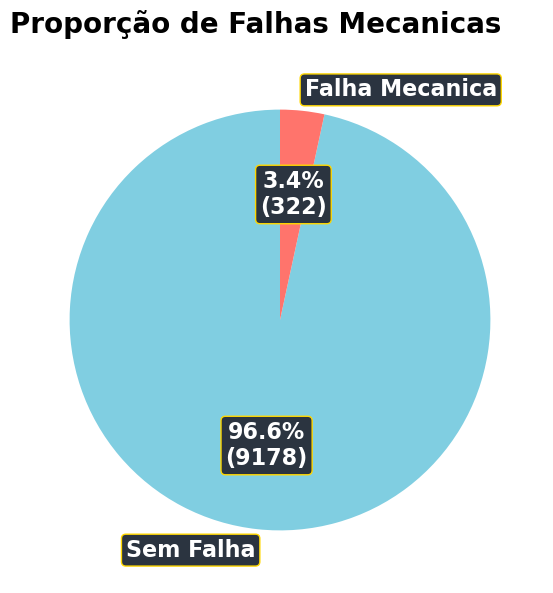

In [5]:
# Distribuição da variavel target (falha_maquina)

fig, ax = plt.subplots(figsize = (18, 6))
fig.suptitle('Proporção de Falhas Mecanicas', fontsize = 20, fontweight = 'bold', x=0.35,  ha='left')

ax.pie(df['falha_maquina'].value_counts(),
        labels = df['falha_maquina'].value_counts().index.map({0 : 'Sem Falha', 1 : 'Falha Mecanica'}),
        autopct = lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(df['falha_maquina'].value_counts()))})',
        startangle = 90,
        colors=['#80cee1','#FF746c'],
        textprops = {
            'color' : 'white',
            'fontsize' : 16,
            'fontweight': 'bold',
            'bbox': { 
                    'boxstyle': 'round',
                    'edgecolor': 'gold',
                    'facecolor': '#2b3440',
                    'linewidth': 1,
                    'pad': 0.2
            }           
        }    
       )

plt.tight_layout()

**Dos 9500 registros 322 (3.4%) apresentaram falha**

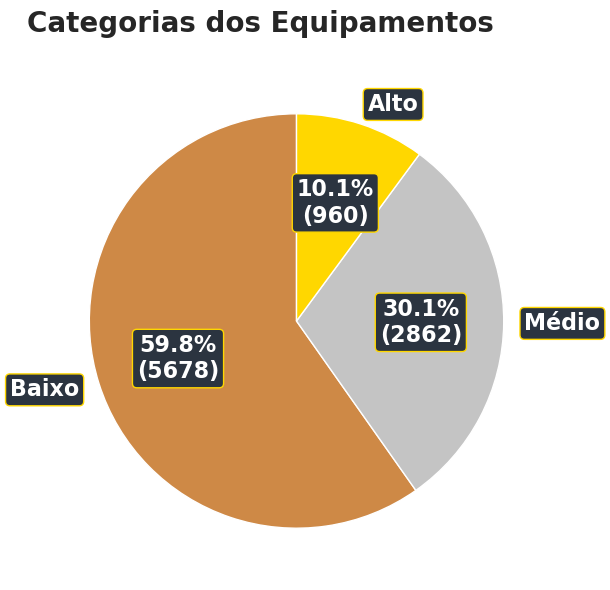

In [27]:
# Distribuição da variavel target (falha_maquina)

fig, ax = plt.subplots(figsize = (18, 6))
fig.suptitle('Categorias dos Equipamentos', fontsize = 20, fontweight = 'bold', x=0.35,  ha='left')

ax.pie(df['tipo'].value_counts(),
        labels = df['tipo'].value_counts().index.map({'L' : 'Baixo', 'M' : 'Médio', 'H': 'Alto'}),
        autopct = lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(df['falha_maquina'].value_counts()))})',
        startangle = 90,
        colors=['#ce8946','#C4C4C4','#FFD700'],
        textprops = {
            'color' : 'white',
            'fontsize' : 16,
            'fontweight': 'bold',
            'bbox': { 
                    'boxstyle': 'round',
                    'edgecolor': 'gold',
                    'facecolor': '#2b3440',
                    'linewidth': 1,
                    'pad': 0.2
            }           
        }    
       )

plt.tight_layout()

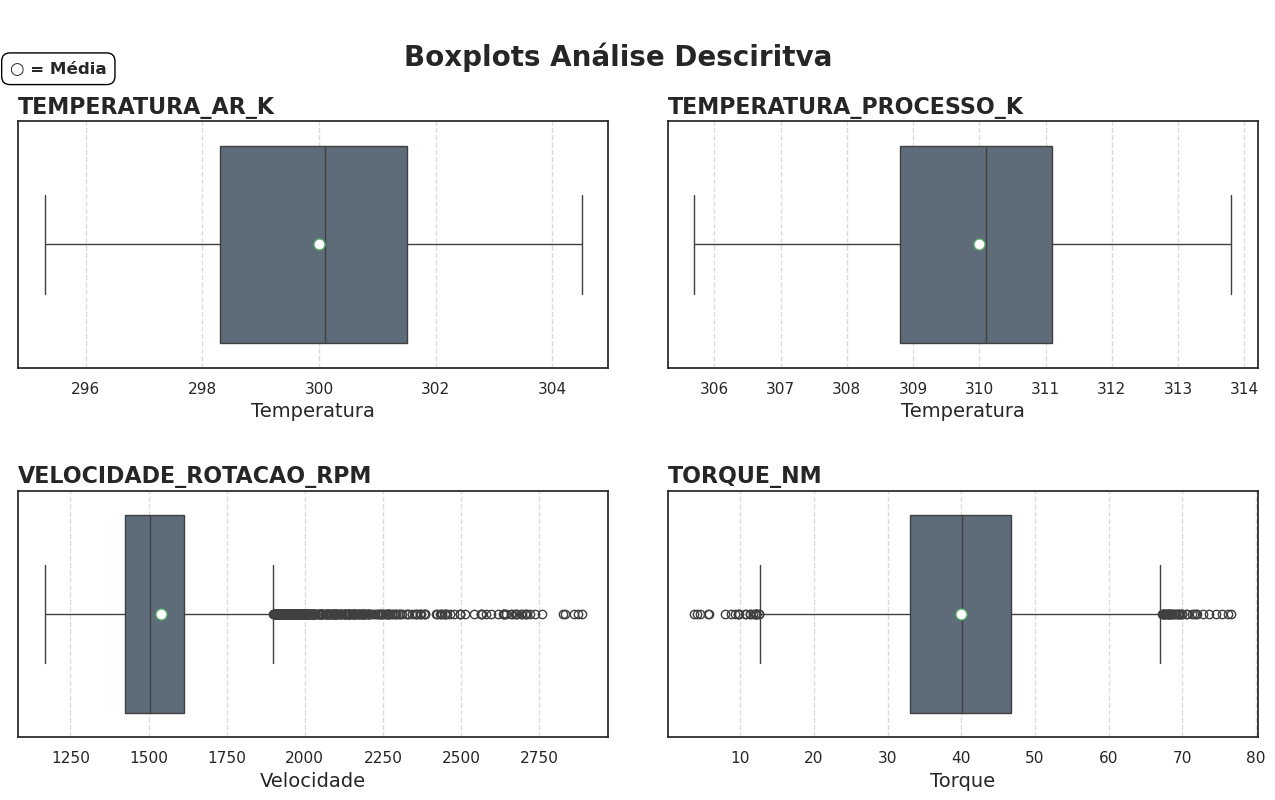

In [32]:
colunas = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']

fig, axs = plt.subplots(2,2, figsize = (16,8))
fig.subplots_adjust(hspace = 0.5, wspace = 0.1)
fig.suptitle('\nBoxplots Análise Desciritva', fontsize = 20,  fontweight = 'bold', y=1.02)

for i, k in zip(axs.ravel(), colunas):
    sns.boxplot(
        data = df,
        x = k,
        color = '#5A6B7C',
        ax = i,
        showmeans=True,
        meanprops={'marker':'o', 'markerfacecolor':'white', 'markersize':'8'})
    
    i.set_title(f'{k.upper()}', fontsize = 16, fontweight = 'bold', loc = 'left')
    i.grid(axis='x', linestyle='--', alpha=0.7)


fig.text(
    0.12,  
    0.94,  
    "○ = Média", 
    fontsize=12, 
    fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

axs[0,0].set_xlabel('Temperatura', fontsize = 14)
axs[0,1].set_xlabel('Temperatura', fontsize = 14)
axs[1,0].set_xlabel('Velocidade', fontsize = 14)
axs[1,1].set_xlabel('Torque', fontsize = 14)

plt.show()

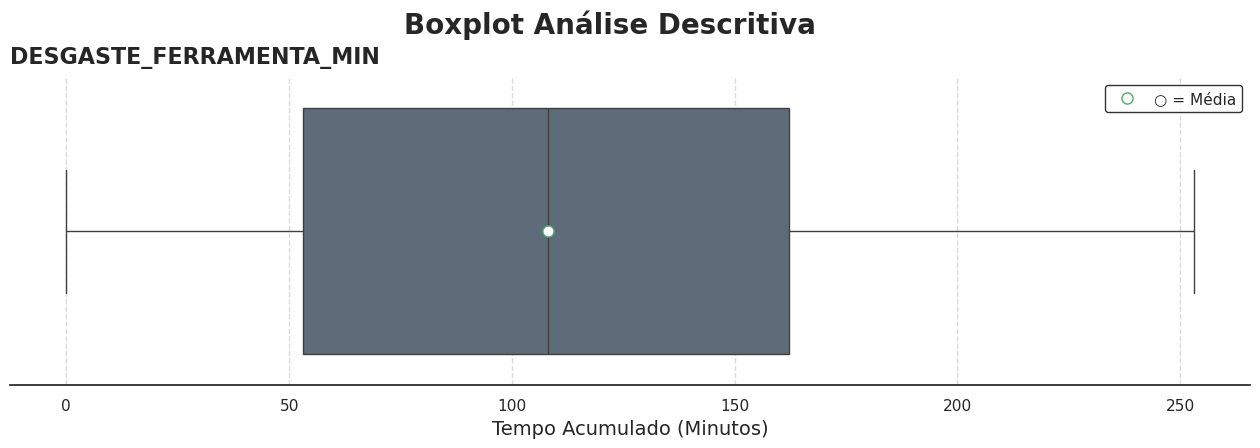

In [31]:
fig, ax = plt.subplots(figsize=(16, 4))
fig.suptitle('Boxplot Análise Descritiva', fontsize=20, fontweight='bold', y=1.05)

sns.boxplot(
    data=df,
    x='desgaste_ferramenta_min',
    ax=ax,
    color = '#5A6B7C',
    showmeans=True,
    meanprops={'marker': 'o', 'markerfacecolor': 'white', 'markersize': '8', 'label': '○ = Média'}
)

ax.set_title('DESGASTE_FERRAMENTA_MIN', fontsize=16, fontweight='bold', loc='left', pad=10)
ax.set_xlabel('Tempo Acumulado (Minutos)', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='black', fontsize=11)

sns.despine(left=True)
plt.show()

## 4.2 - Análises bivariadas

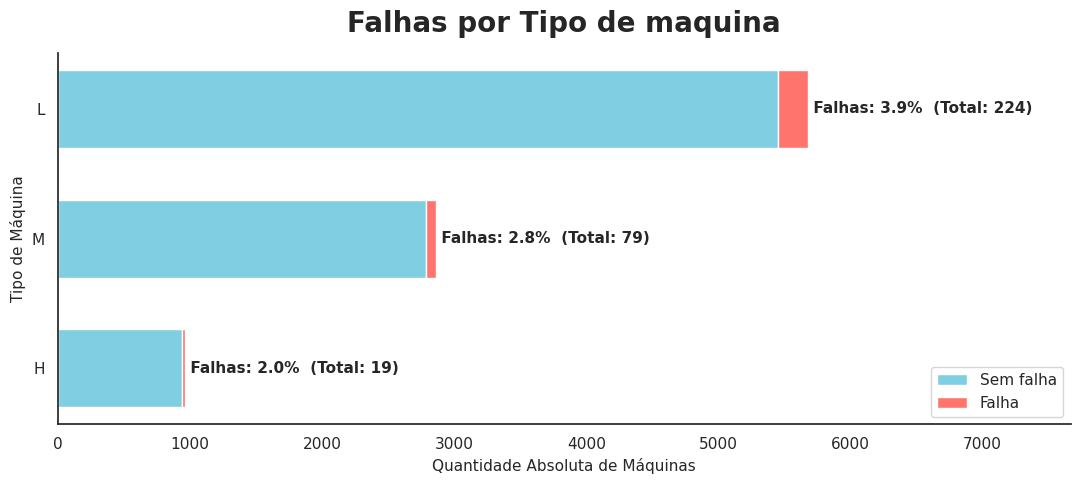

In [19]:
resumo = (
    df.groupby("tipo")
    .agg(
        total_maquinas=("falha_maquina", "count"),
        total_falhas=("falha_maquina", "sum"),
    )
    .reset_index()
)

resumo["sem_falhas"] = resumo["total_maquinas"] - resumo["total_falhas"]
resumo["proporcao_falha"] = (resumo["total_falhas"] / resumo["total_maquinas"]) * 100
resumo = resumo.sort_values(by="total_maquinas", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))

barras_ok = ax.barh(
    resumo["tipo"],
    resumo["sem_falhas"],
    color="#80cee1",  
    height=0.6,
    label="Sem falha",
)

barras_falha = ax.barh(
    resumo["tipo"],
    resumo["total_falhas"],
    left=resumo["sem_falhas"],  
    color="#FF746c",  
    height=0.6,
    label="Falha",
)

for barra, falha_pct, total in zip(
    barras_falha, resumo["proporcao_falha"], resumo["total_falhas"]
):
    fim_da_barra = barra.get_x() + barra.get_width()

    texto_rotulo = f" Falhas: {falha_pct:.1f}%  (Total: {total})"

    ax.text(
        fim_da_barra,  
        barra.get_y() + barra.get_height() / 2,  
        texto_rotulo,
        va="center",
        ha="left",
        fontsize=11,
        weight="bold",
    )

ax.set_title("Falhas por Tipo de maquina", fontsize=20,fontweight = 'bold', pad=15)
ax.set_xlabel("Quantidade Absoluta de Máquinas", fontsize=11)
ax.set_ylabel("Tipo de Máquina", fontsize=11)

ax.set_xlim(0, resumo["total_maquinas"].max() * 1.35)

ax.legend(loc="lower right")

for espinha in ["top", "right"]:
    ax.spines[espinha].set_visible(False)

plt.tight_layout()
plt.show()

Embora as máquinas do tipo L apresentem o dobro da proporção de falhas em comparação ao tipo H, existe um forte desbalanceamento na base: o volume do tipo L é cerca de 6 vezes maior. Além disso, o gráfico sugere uma correlação positiva entre o volume de equipamentos e a taxa de falhas. Esse cenário torna difícil inferir, apenas com esta visualização, se as falhas são causadas pelo tipo da máquina ou se são um reflexo do desbalanceamento de volume.

In [9]:
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
4,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0


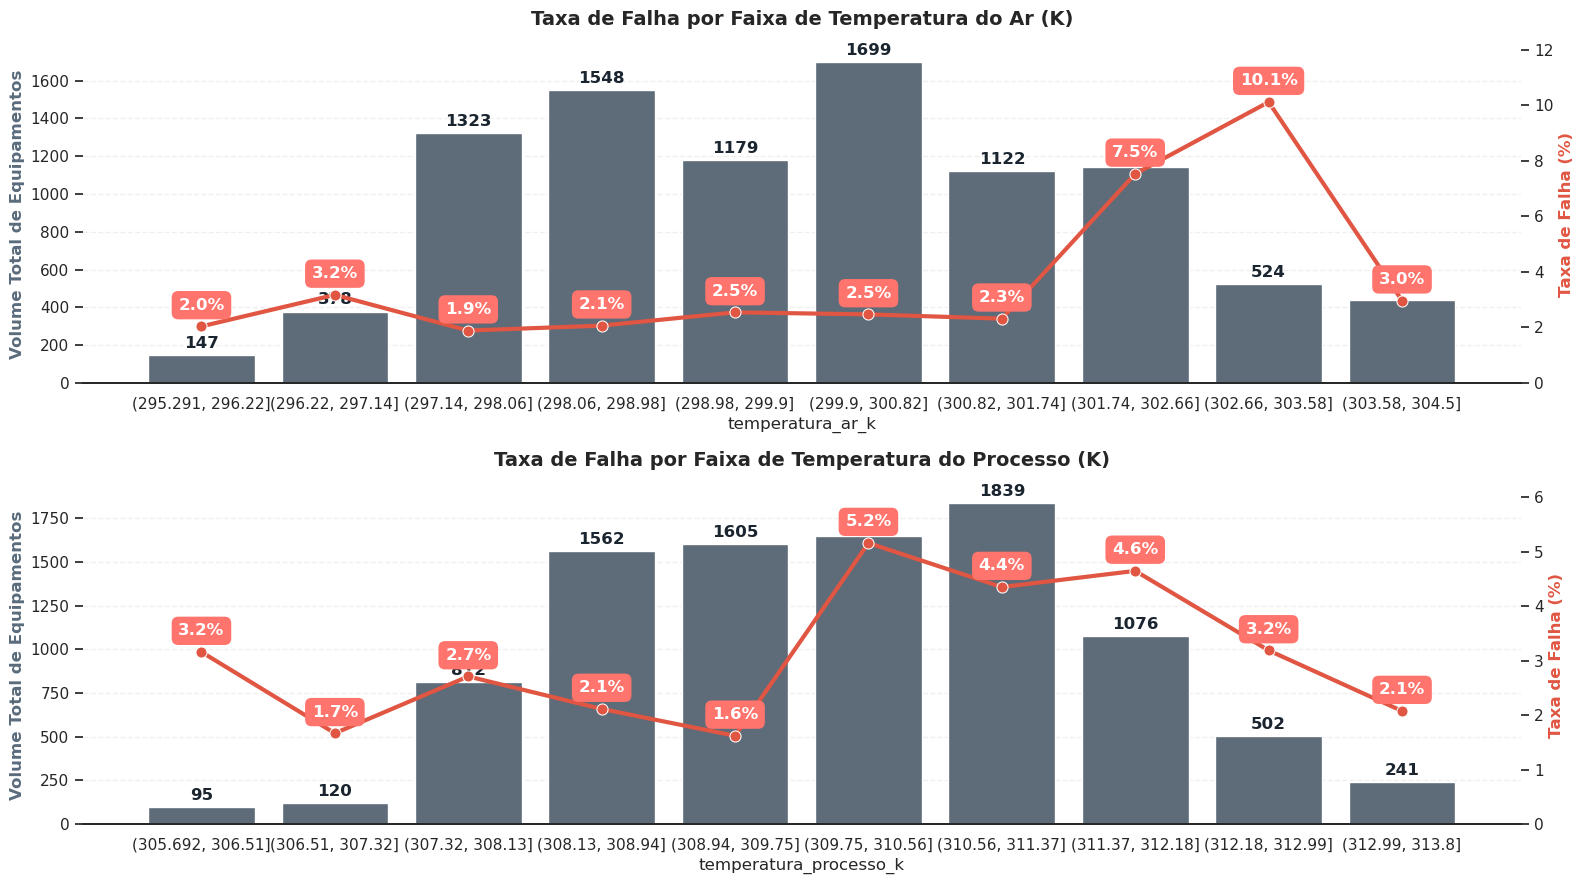

In [26]:
sns.set_theme(style="white", rc={"figure.figsize": (16, 9)})
fig, axs = plt.subplots(2, 1, sharex=False)

cols = ["temperatura_ar_k", "temperatura_processo_k"]
titulos = ["Taxa de Falha por Faixa de Temperatura do Ar (K)", "Taxa de Falha por Faixa de Temperatura do Processo (K)"]

for i, col in enumerate(cols):
    ax1 = axs[i]

    df_bin = df.groupby(pd.cut(df[col], bins=10), observed=False)["falha_maquina"].agg(["count", "mean"]).reset_index()
    df_bin[col] = df_bin[col].astype(str)
    df_bin["taxa_pct"] = df_bin["mean"] * 100  

    sns.barplot(data=df_bin, x=col, y="count", color="#5A6B7C", ax=ax1)
    ax1.set_ylabel("Volume Total de Equipamentos", color="#5A6B7C", fontweight="bold")
    ax1.set_title(titulos[i], fontsize=14, pad=15, fontweight="bold")
    ax1.bar_label(ax1.containers[0], padding=3, color="#1A2530", fontweight="bold")

    ax2 = ax1.twinx()
    sns.lineplot(data=df_bin, x=col, y="taxa_pct", color="#E05643", marker="o", linewidth=3, markersize=8, ax=ax2)
    ax2.set_ylabel("Taxa de Falha (%)", color="#E05643", fontweight="bold")

    ax2.set_ylim(0, df_bin["taxa_pct"].max() * 1.2)

    for idx, row in df_bin.iterrows():
        ax2.annotate(f"{row['taxa_pct']:.1f}%", (idx, row['taxa_pct']), textcoords="offset points", 
                     xytext=(0,12), ha='center', color='white', fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.4", fc="#FF746c", ec="none"))

    ax1.spines[['top', 'left', 'right']].set_visible(False)
    ax2.spines[['top', 'left', 'right']].set_visible(False)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Em relação à temperatura do ar, a taxa de falhas apresenta um salto evidente de 2,3% para 10,1% na faixa entre 301K e 303K. Acima de 303K, porém, essa taxa cai abruptamente para 3%. Esse pico sugere uma correlação em uma faixa térmica específica, mas não define causalidade.

Já na temperatura do processo, o comportamento também não é linear. Observa-se uma elevação de 1,6% para 5,2% entre 309K e 310K, mantendo-se acima de 4% até 312K. Após esse pico, a taxa recua para 2,1% aos 313K. Além disso, as temperaturas mais baixas (305K a 306K) apresentam 3,2% de falhas, mas possuem uma baixíssima volumetria (apenas 95 registros). Essa quebra de linearidade e a variação no volume da amostra tornam difícil estabelecer visualmente uma relação causal direta entre a temperatura do processo e as falhas no equipamento.

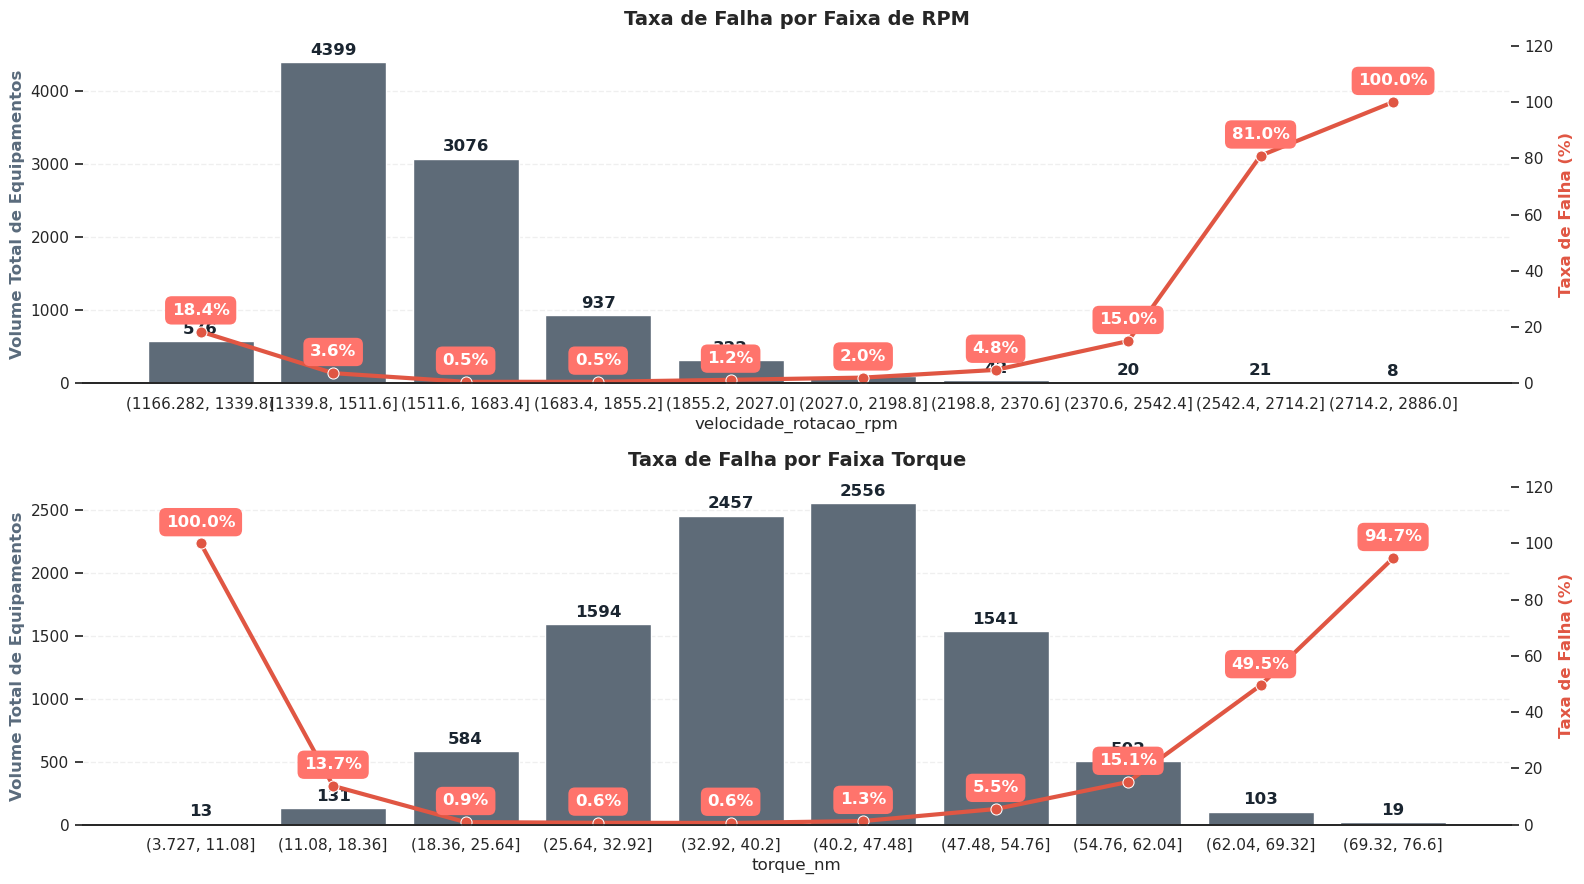

In [25]:
fig, axs = plt.subplots(2, 1, sharex=False)

cols = ["velocidade_rotacao_rpm", "torque_nm"]
titulos = ["Taxa de Falha por Faixa de RPM", "Taxa de Falha por Faixa Torque"]

for i, col in enumerate(cols):
    ax1 = axs[i]

    df_bin = df.groupby(pd.cut(df[col], bins=10), observed=False)["falha_maquina"].agg(["count", "mean"]).reset_index()
    df_bin[col] = df_bin[col].astype(str)
    df_bin["taxa_pct"] = df_bin["mean"] * 100  

    sns.barplot(data=df_bin, x=col, y="count", color="#5A6B7C", ax=ax1)
    ax1.set_ylabel("Volume Total de Equipamentos", color="#5A6B7C", fontweight="bold")
    ax1.set_title(titulos[i], fontsize=14, pad=15, fontweight="bold")
    ax1.bar_label(ax1.containers[0], padding=3, color="#1A2530", fontweight="bold")

    ax2 = ax1.twinx()
    sns.lineplot(data=df_bin, x=col, y="taxa_pct", color="#E05643", marker="o", linewidth=3, markersize=8, ax=ax2)
    ax2.set_ylabel("Taxa de Falha (%)", color="#E05643", fontweight="bold")

    ax2.set_ylim(0, df_bin["taxa_pct"].max() * 1.2)

    for idx, row in df_bin.iterrows():
        ax2.annotate(f"{row['taxa_pct']:.1f}%", (idx, row['taxa_pct']), textcoords="offset points", 
                     xytext=(0,12), ha='center', color='white', fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.4", fc="#FF746c", ec="none"))

    ax1.spines[['top', 'left', 'right']].set_visible(False)
    ax2.spines[['top', 'left', 'right']].set_visible(False)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Tanto o RPM quanto o Torque apresentam uma baixa proporção de falhas quando operam em torno de suas médias (1.539 e 40, respectivamente). À medida que os valores se distanciam desse centro — seja para mais ou para menos —, a taxa de falhas sobe de forma consistente. Esse comportamento sugere a existência de uma faixa ideal de operação: operar o equipamento fora desses limites térmicos e mecânicos aumenta consideravelmente a probabilidade de quebra, indicando uma forte relação de causa e efeito.

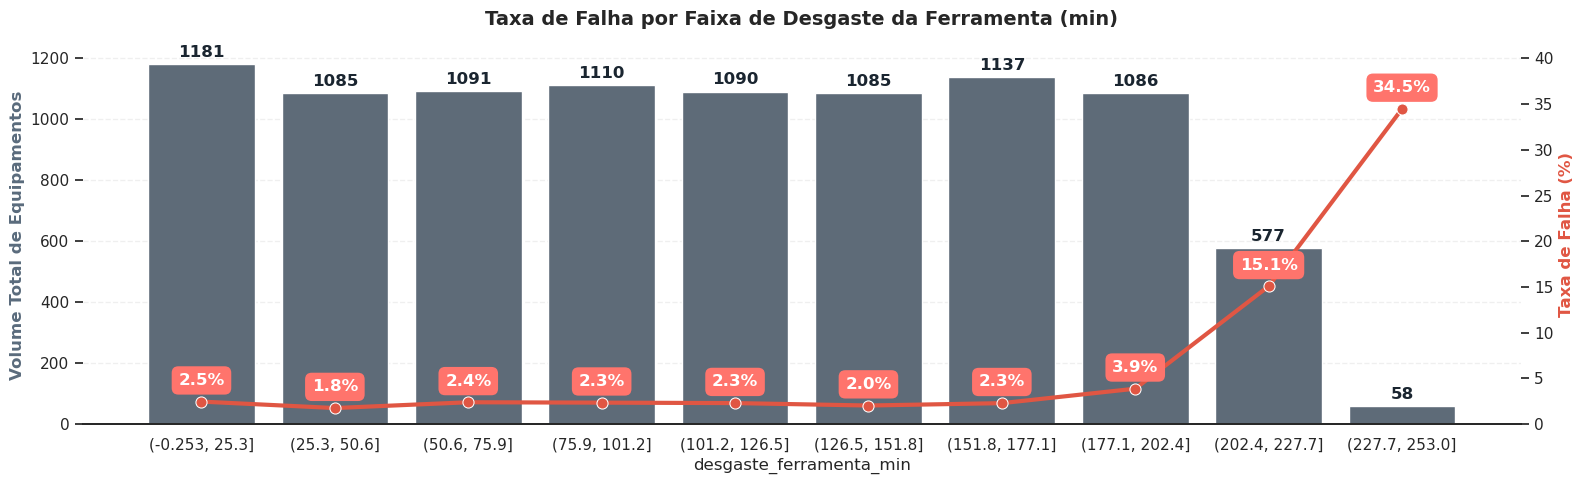

In [24]:
fig, ax1 = plt.subplots(figsize=(16, 5))

df_bin = df.groupby(pd.cut(df["desgaste_ferramenta_min"], bins=10), observed=False)["falha_maquina"].agg(["count", "mean"]).reset_index()
df_bin["desgaste_ferramenta_min"] = df_bin["desgaste_ferramenta_min"].astype(str)
df_bin["taxa_pct"] = df_bin["mean"] * 100

sns.barplot(data=df_bin, x="desgaste_ferramenta_min", y="count", color="#5A6B7C", ax=ax1)
ax1.set_ylabel("Volume Total de Equipamentos", color="#5A6B7C", fontweight="bold")
ax1.set_title("Taxa de Falha por Faixa de Desgaste da Ferramenta (min)", fontsize=14, pad=15, fontweight="bold")
ax1.bar_label(ax1.containers[0], padding=3, color="#1A2530", fontweight="bold")

ax2 = ax1.twinx()
sns.lineplot(data=df_bin, x="desgaste_ferramenta_min", y="taxa_pct", color="#E05643", marker="o", linewidth=3, markersize=8, ax=ax2)
ax2.set_ylabel("Taxa de Falha (%)", color="#E05643", fontweight="bold")

ax2.set_ylim(0, df_bin["taxa_pct"].max() * 1.2 if df_bin["taxa_pct"].max() > 0 else 10)

for idx, row in df_bin.iterrows():
    ax2.annotate(f"{row['taxa_pct']:.1f}%", (idx, row['taxa_pct']), textcoords="offset points", 
                 xytext=(0,12), ha='center', color='white', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.4", fc="#FF746c", ec="none"))
    
ax1.spines[['top', 'left', 'right']].set_visible(False)
ax2.spines[['top', 'left', 'right']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

O gráfico revela um claro ponto de virada (limiar de desgaste) relacionado ao tempo de uso. Em operações de até 177 minutos, a taxa de falhas é estável e baixa, na casa dos 2,3%. No entanto, após cruzar esse limite, a probabilidade de falha aumenta drasticamente, atingindo um pico de 34,5% em operações que ultrapassam a marca de 227 minutos.

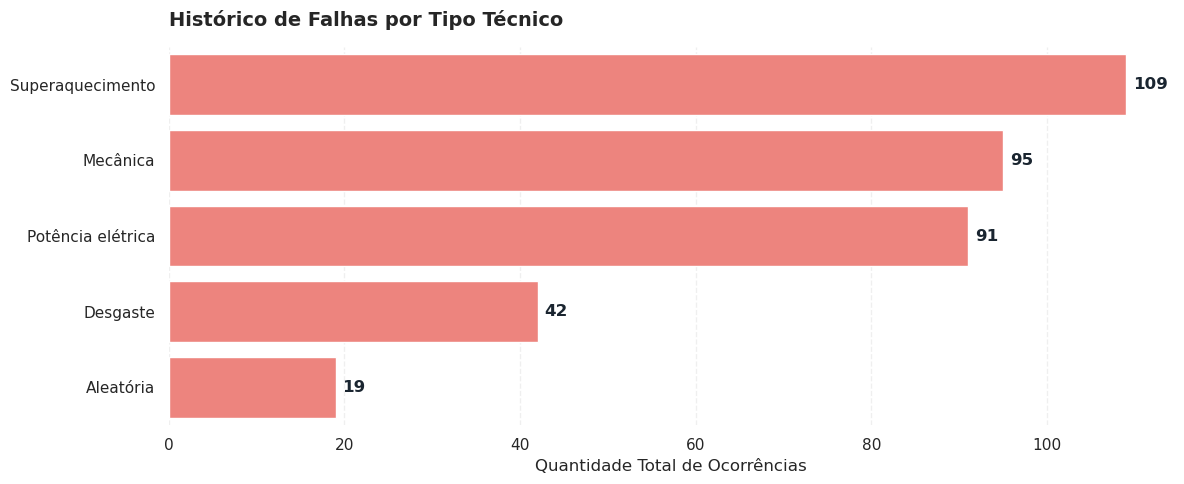

In [23]:
colunas_falha = ['falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
nomes_corretos = {'falha_twf': 'Desgaste', 'falha_hdf': 'Superaquecimento', 'falha_pwf': 'Potência elétrica', 'falha_osf': 'Mecânica', 'falha_rnf': 'Aleatória'}

df_falhas = df[colunas_falha].sum().rename(nomes_corretos).sort_values(ascending=False).reset_index()
df_falhas.columns = ['Tipo de Falha', 'Total']

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_falhas, x='Total', y='Tipo de Falha', color='#FF746c', ax=ax)

ax.set_title('Histórico de Falhas por Tipo Técnico', fontsize=14, pad=15, fontweight='bold', loc='left')
ax.set_xlabel('Quantidade Total de Ocorrências', fontsize=12)
ax.set_ylabel('') # Remove o título do eixo Y já que os nomes são autoexplicativos
ax.bar_label(ax.containers[0], padding=5, color='#1A2530', fontweight='bold')

sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 5 - Feature Engineering e Análise

## 5.1 Feature Engineering

In [33]:
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
4,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0


### ALteções que serão realizadas

- **Criação de variaveis**:
    - `potencia` : Multiplicação das colunas velocidade_rotacao_rpm * torque_nm
    - `delta_temperatura` : Diferença da temperatura ambiente para temperatura do processo temperatura_ar_k - temperatura_processo_k
- **Ordinal Encoding**:
    - `tipo`: Por se tratar de uma variavel `categorica ordinal` os valores L, M e H serão alterados para 1, 2 e 3 respectivamente, garantindo sua aceitação pelo modelo de machine learnig futuramente

In [ ]:
# Copia do df atual
